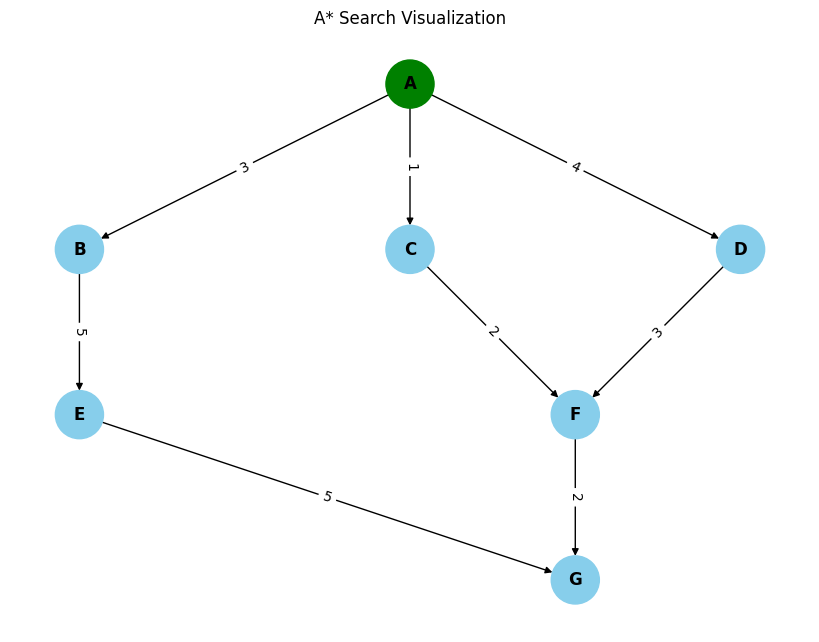

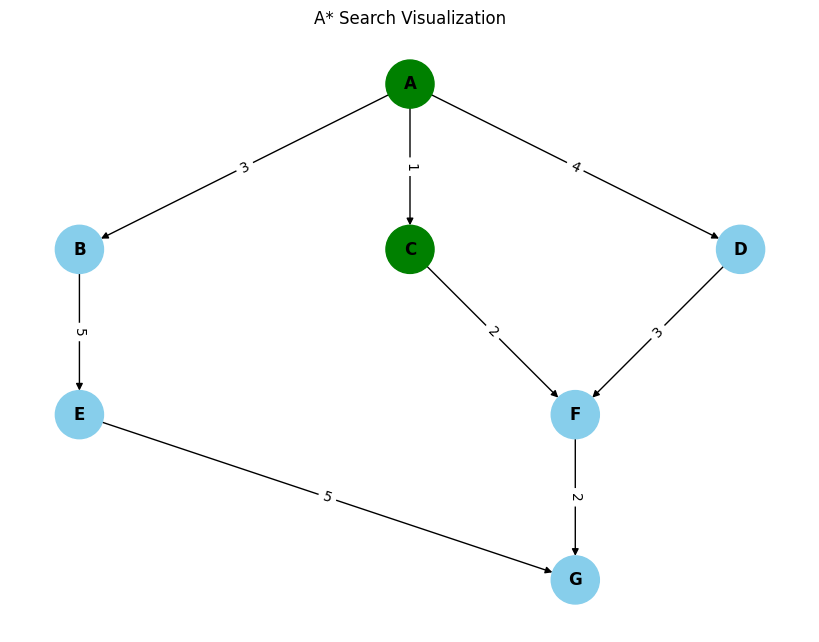

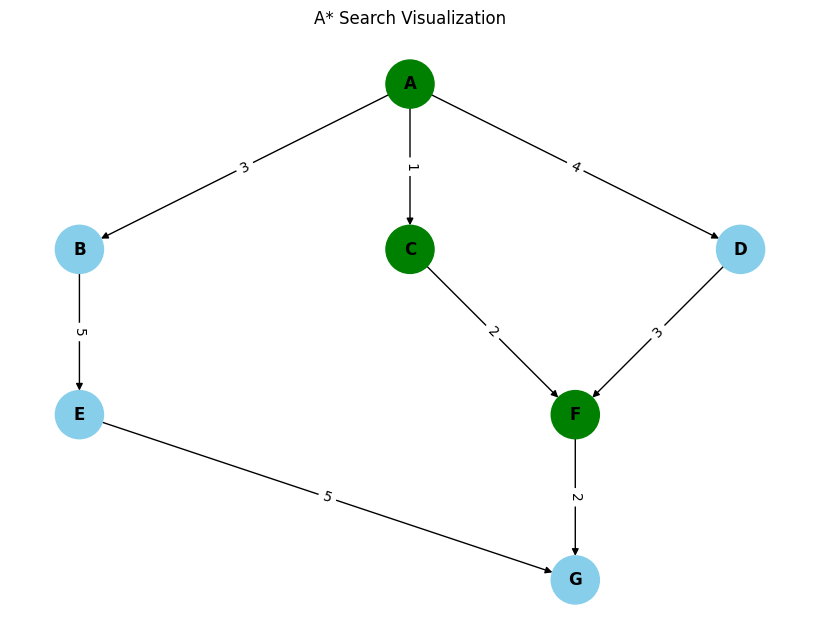

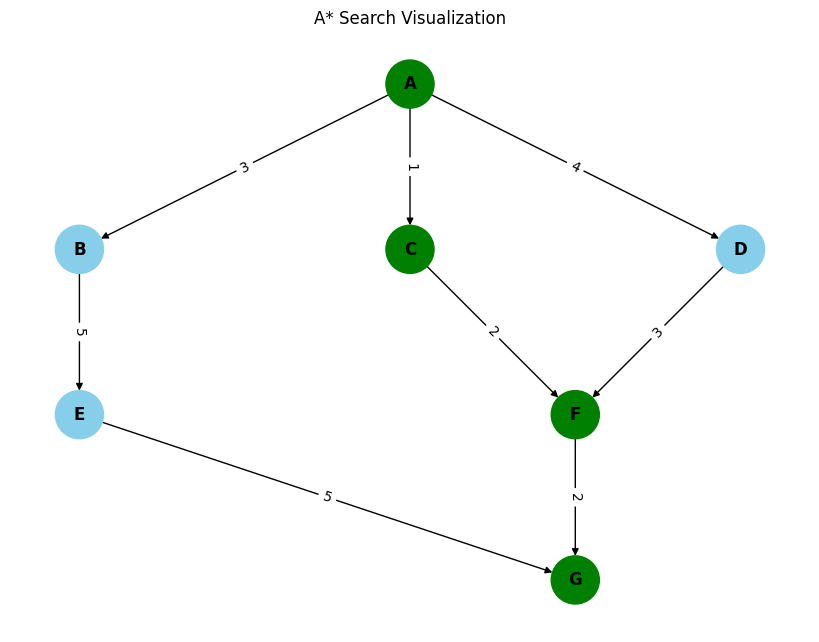

Expansion Order:
Expand A
Expand C
Expand F
Expand G

Optimal Path: A -> C -> F -> G
Total Cost: 5


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# Graph with edge costs
graph = {
    'A': {'B': 3, 'C': 1, 'D': 4},
    'B': {'E': 5},
    'C': {'F': 2},
    'D': {'F': 3},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

# Heuristic values
heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 5,
    'E': 3,
    'F': 1,
    'G': 0
}

# Create NetworkX graph
G = nx.DiGraph()
for node in graph:
    for neighbor, cost in graph[node].items():
        G.add_edge(node, neighbor, weight=cost)

# Node positions
pos = {
    'A': (0, 2),
    'B': (-1, 1),
    'C': (0, 1),
    'D': (1, 1),
    'E': (-1, 0),
    'F': (0.5, 0),
    'G': (0.5, -1)
}

def draw_graph(current=None, visited=None, path=None):
    plt.figure(figsize=(8, 6))

    colors = []
    for node in G.nodes():
        if path and node in path:
            colors.append("green")
        elif current == node:
            colors.append("red")
        elif visited and node in visited:
            colors.append("yellow")
        else:
            colors.append("skyblue")

    nx.draw(G, pos, with_labels=True,
            node_color=colors,
            node_size=1200,
            font_weight='bold',
            arrows=True)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("A* Search Visualization")
    plt.show()

def astar(start, goal):
    pq = []
    heapq.heappush(pq, (heuristic[start], 0, start, [start]))

    visited = set()
    expansion_order = []

    while pq:
        f, g, node, path = heapq.heappop(pq)

        if node in visited:
            continue

        visited.add(node)
        expansion_order.append(node)

        draw_graph(current=node, visited=visited, path=path)

        if node == goal:
            return path, g, expansion_order

        for neighbor, cost in graph[node].items():
            if neighbor not in visited:
                g_new = g + cost
                f_new = g_new + heuristic[neighbor]
                heapq.heappush(pq, (f_new, g_new, neighbor, path + [neighbor]))

    return None, float('inf'), expansion_order

# Run A*
path, cost, order = astar('A', 'G')

print("Expansion Order:")
for node in order:
    print("Expand", node)

print("\nOptimal Path:", " -> ".join(path))
print("Total Cost:", cost)